In [0]:
import warnings 
warnings.filterwarnings('ignore')

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

## Question 1

Import the data set and print 10 random rows from the data set

In [138]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
from sklearn.naive_bayes import GaussianNB

# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

In [3]:
NNH = KNeighborsClassifier(n_neighbors= 21)

In [5]:
colnames = ['sepal length in cm','sepal width in cm','petal length in cm','petal width in cm','class']
iris_df = pd.read_csv("iris.data", names= colnames) 
iris_df.head(10)

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [13]:
iris_df.info()
iris_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal length in cm    150 non-null float64
sepal width in cm     150 non-null float64
petal length in cm    150 non-null float64
petal width in cm     150 non-null float64
class                 150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


sepal length in cm    0
sepal width in cm     0
petal length in cm    0
petal width in cm     0
class                 0
dtype: int64

In [18]:
iris_df[iris_df['petal width in cm'] == 0]
iris_df['sepal length in cm']=iris_df['sepal length in cm'].replace(0, iris_df['sepal length in cm'].median())
iris_df['sepal width in cm']=iris_df['sepal width in cm'].replace(0, iris_df['sepal width in cm'].median())
iris_df['petal length in cm']=iris_df['petal length in cm'].replace(0, iris_df['petal length in cm'].median())
iris_df['petal width in cm']=iris_df['petal width in cm'].replace(0, iris_df['petal width in cm'].median())

## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

In [21]:
iris_df['class'].value_counts()
iris_df['class']= iris_df['class'].replace({'Iris-virginica': 0,'Iris-versicolor':1, 'Iris-setosa':2})
iris_df.head()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,class
0,5.1,3.5,1.4,0.2,2
1,4.9,3.0,1.4,0.2,2
2,4.7,3.2,1.3,0.2,2
3,4.6,3.1,1.5,0.2,2
4,5.0,3.6,1.4,0.2,2


 ## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

In [22]:
iris_df.corr()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,class
sepal length in cm,1.000000,-0.109369,0.871754,0.817954,-0.782561
sepal width in cm,-0.109369,1.000000,-0.420516,-0.356544,0.419446
petal length in cm,0.871754,-0.420516,1.000000,0.962757,-0.949043
petal width in cm,0.817954,-0.356544,0.962757,1.000000,-0.956464
class,-0.782561,0.419446,-0.949043,-0.956464,1.000000


### it is observed that there correlation between the independent Variables with Target Variable is not in range -0.1 to 0.1, so no need to drop variables from feature.

## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [23]:
iris_df.var()

sepal length in cm    0.685694
sepal width in cm     0.188004
petal length in cm    3.113179
petal width in cm     0.582414
class                 0.671141
dtype: float64

### it is observed that no Feature or independent Variable has low Variance (Variance<0.1), so no need to drop any feature.

## Question 6

*Plot the scatter matrix for all the variables.*

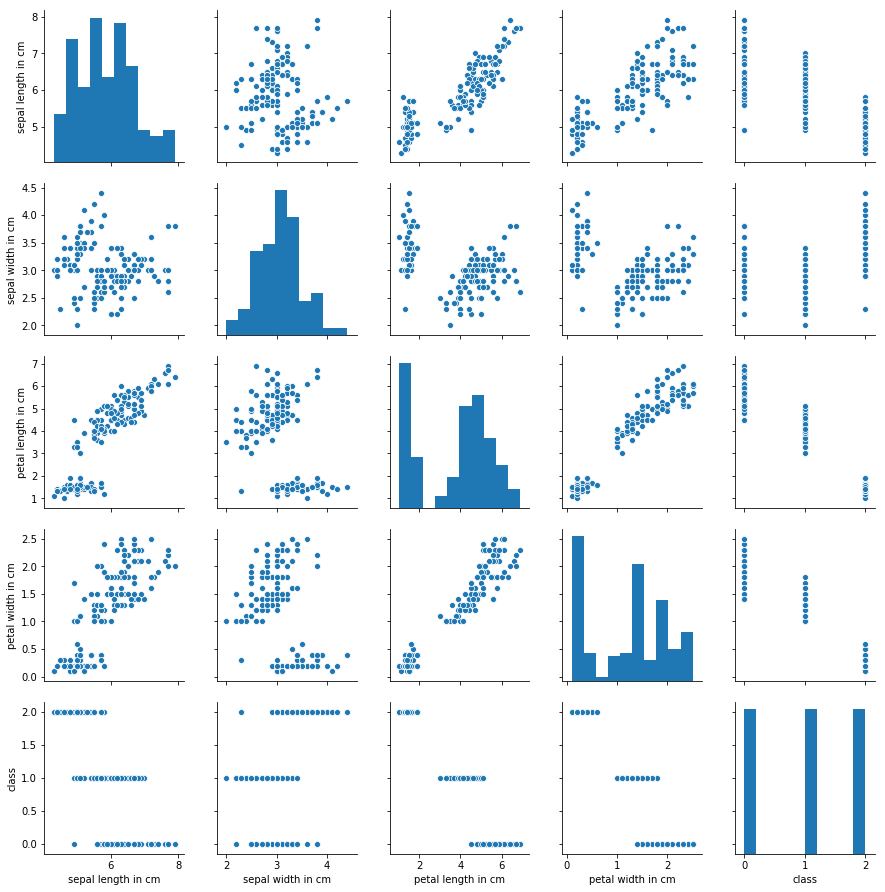

In [24]:
sns.pairplot(iris_df)

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [25]:
X = iris_df.drop("class", axis=1)
y = iris_df["class"]
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [51]:
# instantiate learning model (k = 3)
knn = KNeighborsClassifier(n_neighbors=3)

# fitting the model
knn.fit(X_train, y_train)

# predict the response
pred = knn.predict(X_test)

# evaluate accuracy
# print accuracy_score(y_test, pred)

acc1=metrics.accuracy_score(y_test,pred)
print('accuracy_score for k=3 is: ', acc1)

knn = KNeighborsClassifier(n_neighbors=5)

# fitting the model
knn.fit(X_train, y_train)

# predict the response
pred = knn.predict(X_test)

# evaluate accuracy
# print accuracy_score(y_test, pred)

acc1=metrics.accuracy_score(y_test,pred)
print('accuracy_score for k=5 is: ', acc1)

knn = KNeighborsClassifier(n_neighbors=9)

# fitting the model
knn.fit(X_train, y_train)

# predict the response
pred = knn.predict(X_test)

# evaluate accuracy
# print accuracy_score(y_test, pred)

acc1=metrics.accuracy_score(y_test,pred)
print('accuracy_score for k=9 is: ', acc1)


accuracy_score for k=3 is:  0.9
accuracy_score for k=5 is:  0.9
accuracy_score for k=9 is:  0.9


## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [92]:
# creating odd list of K for KNN
myList = list(range(1,20))

# subsetting just the odd ones
neighbors = list(filter(lambda x: x % 2 != 0, myList))
# print (list(neighbors))
# empty list that will hold cv scores
cv_scores = []
kl=[]
# perform 10-fold cross validation
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())
    kl.append(k)
    # print ('accuraccy for k= ',k,' is: ',cv_scores)
pd.DataFrame(data=cv_scores,index=kl)
  

,0
1,0.972576
3,0.972576
5,0.981667
7,0.972576
9,0.983974
11,0.983974
13,0.991667
15,0.991667
17,0.982576
19,0.991667


In [82]:
# changing to misclassification error
MSE = [1 - x for x in cv_scores]

# determining best k
optimal_k = neighbors[MSE.index(min(MSE))]
print ("The optimal number of neighbors is ", optimal_k)



The optimal number of neighbors is  13


## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

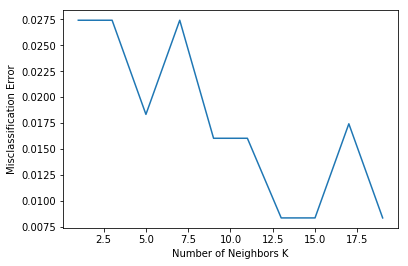

In [84]:
# plot misclassification error vs k
plt.plot(neighbors, MSE)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Misclassification Error')
plt.show()

# Naive Bayes with Iris Data

In [139]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [95]:
new_columns = iris_df.columns.values; new_columns[4] = 'Species'; iris_df.columns = new_columns
iris_df.head()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,Species
0,5.1,3.5,1.4,0.2,2
1,4.9,3.0,1.4,0.2,2
2,4.7,3.2,1.3,0.2,2
3,4.6,3.1,1.5,0.2,2
4,5.0,3.6,1.4,0.2,2


In [97]:
X = iris_df.drop("Species", axis=1)
y = iris_df["Species"]

In [98]:
#Check the dataset
print(y)
print(X)

0      2
1      2
2      2
3      2
4      2
5      2
6      2
7      2
8      2
9      2
10     2
11     2
12     2
13     2
14     2
15     2
16     2
17     2
18     2
19     2
20     2
21     2
22     2
23     2
24     2
25     2
26     2
27     2
28     2
29     2
      ..
120    0
121    0
122    0
123    0
124    0
125    0
126    0
127    0
128    0
129    0
130    0
131    0
132    0
133    0
134    0
135    0
136    0
137    0
138    0
139    0
140    0
141    0
142    0
143    0
144    0
145    0
146    0
147    0
148    0
149    0
Name: Species, Length: 150, dtype: int64
     sepal length in cm  sepal width in cm  petal length in cm  \
0                   5.1                3.5                 1.4   
1                   4.9                3.0                 1.4   
2                   4.7                3.2                 1.3   
3                   4.6                3.1                 1.5   
4                   5.0                3.6                 1.4   
5             

In [100]:
 # new_columns = iris_df.columns.values; new_columns[4] = 'class'; iris_df.columns = new_columns
# iris_df.head()

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

(array([50.,  0.,  0.,  0.,  0., 50.,  0.,  0.,  0., 50.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <a list of 10 Patch objects>)

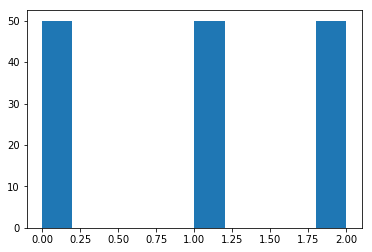

In [101]:
plt.hist(iris_df['Species'])

In [0]:
#Drop Id variable from data

### Question 12 
Find Correlation among all variables and give your insights 

In [0]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

In [102]:
iris_df.corr()

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,Species
sepal length in cm,1.000000,-0.109369,0.871754,0.817954,-0.782561
sepal width in cm,-0.109369,1.000000,-0.420516,-0.356544,0.419446
petal length in cm,0.871754,-0.420516,1.000000,0.962757,-0.949043
petal width in cm,0.817954,-0.356544,0.962757,1.000000,-0.956464
Species,-0.782561,0.419446,-0.949043,-0.956464,1.000000


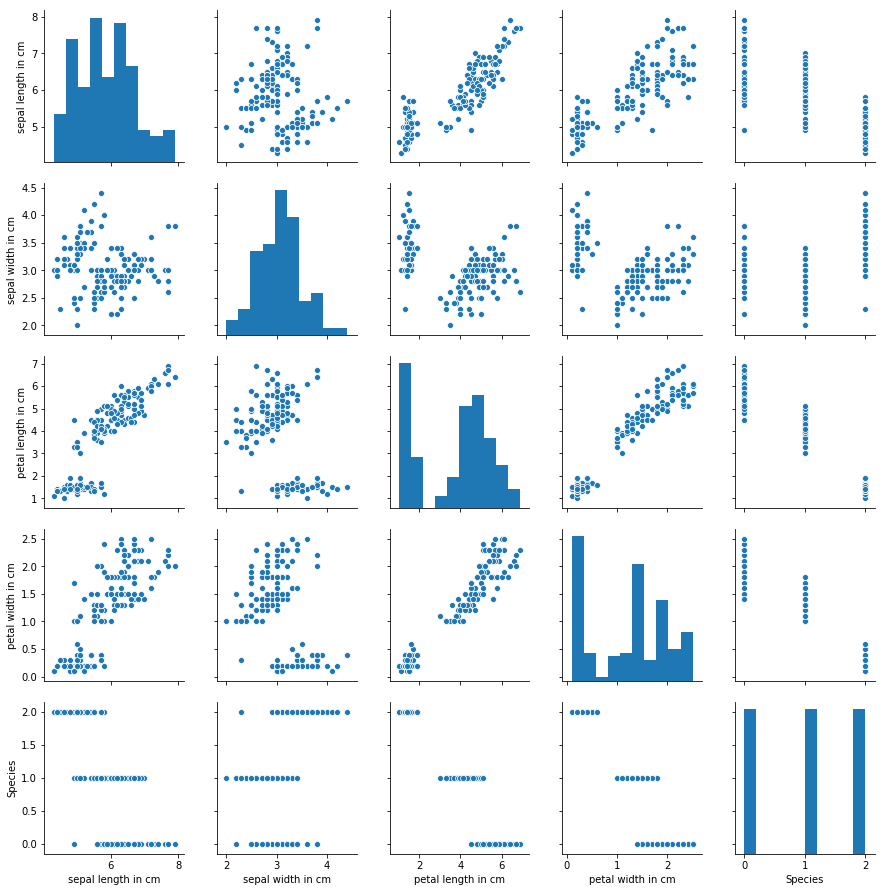

In [103]:
sns.pairplot(iris_df)

insights: 1) Variable "sepal width in cm" is Normally Distributed while "sepal length in cm" is little bit have normal distribution
2) Variables "petal width in cm" and "petal width in cm" are little bit right skewed
3) Variables "petal width in cm" and "petal width in cm" have somewhat Exponential Distribution

### Split data in Training and test set in 80:20.

In [163]:
iris_df1 = iris_df.set_index("Species") 
iris_df1 = iris_df1.drop([2], axis=0)
iris_df1.reset_index(inplace=True)
iris_df1
# iris_df
# iris_df1 = iris_df1.drop([2], axis=0)

,Species,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm
0,1,7.0,3.2,4.7,1.4
1,1,6.4,3.2,4.5,1.5
2,1,6.9,3.1,4.9,1.5
3,1,5.5,2.3,4.0,1.3
4,1,6.5,2.8,4.6,1.5
5,1,5.7,2.8,4.5,1.3
6,1,6.3,3.3,4.7,1.6
7,1,4.9,2.4,3.3,1.0
8,1,6.6,2.9,4.6,1.3
9,1,5.2,2.7,3.9,1.4


In [180]:
iris_df2 = iris_df.set_index("Species") 
iris_df2 = iris_df2.drop([0], axis=0)
iris_df2.reset_index(inplace=True)
iris_df2['Species']= iris_df2['Species'].replace({1: 0,2:1})
iris_df2

,Species,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm
0,1,5.1,3.5,1.4,0.2
1,1,4.9,3.0,1.4,0.2
2,1,4.7,3.2,1.3,0.2
3,1,4.6,3.1,1.5,0.2
4,1,5.0,3.6,1.4,0.2
5,1,5.4,3.9,1.7,0.4
6,1,4.6,3.4,1.4,0.3
7,1,5.0,3.4,1.5,0.2
8,1,4.4,2.9,1.4,0.2
9,1,4.9,3.1,1.5,0.1


In [182]:
iris_df3 = iris_df.set_index("Species") 
iris_df3 = iris_df3.drop([1], axis=0)
iris_df3.reset_index(inplace=True)
iris_df3['Species']= iris_df3['Species'].replace({2:1})
iris_df3

,Species,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm
0,1,5.1,3.5,1.4,0.2
1,1,4.9,3.0,1.4,0.2
2,1,4.7,3.2,1.3,0.2
3,1,4.6,3.1,1.5,0.2
4,1,5.0,3.6,1.4,0.2
5,1,5.4,3.9,1.7,0.4
6,1,4.6,3.4,1.4,0.3
7,1,5.0,3.4,1.5,0.2
8,1,4.4,2.9,1.4,0.2
9,1,4.9,3.1,1.5,0.1


In [164]:
X = iris_df1.drop("Species", axis=1)
y = iris_df1["Species"]
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [183]:
X1 = iris_df2.drop("Species", axis=1)
y1 = iris_df2["Species"]
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=test_size, random_state=seed)

In [184]:
X2 = iris_df3.drop("Species", axis=1)
y2 = iris_df3["Species"]
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=test_size, random_state=seed)

### Question 13 
Do Feature Scaling 

In [165]:
# Use StandardScaler or similar methods
from sklearn.preprocessing import StandardScaler 

In [185]:
scaler=StandardScaler()
scaler.fit(iris_df1)
scaler.fit(iris_df2)
scaler.fit(iris_df3)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)


StandardScaler(copy=True, with_mean=True, with_std=True)

### Question 14 
Train and Fit NaiveBayes Model

In [186]:
#Fit the model
model1 = GaussianNB()
model2 = GaussianNB()
model3 = GaussianNB()
model1.fit(X_train, y_train)
model2.fit(X1_train, y1_train)
model3.fit(X2_train, y2_train)
print(model1)
print(model2)
print(model3)

GaussianNB(priors=None, var_smoothing=1e-09)
GaussianNB(priors=None, var_smoothing=1e-09)
GaussianNB(priors=None, var_smoothing=1e-09)


In [187]:
#Predict
# y_predict = model.predict(X_test)
# make predictions
predicted1 = model.predict(X_test)
predicted2 = model.predict(X1_test)
predicted3 = model.predict(X2_test)

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [189]:
# show Confusion Matrix
metrics.confusion_matrix(predicted1, y_test)

array([[ 8,  1],
       [ 0, 11]], dtype=int64)

In [190]:
metrics.confusion_matrix(predicted2, y1_test)

array([[ 1,  0],
       [ 7, 12]], dtype=int64)

In [191]:
metrics.confusion_matrix(predicted3, y2_test)

array([[ 8,  0],
       [ 0, 12]], dtype=int64)

In [170]:
sum(y_test)

12

In [195]:
y1_predictProb = model1.predict_proba(X_test)

In [196]:
y2_predictProb = model2.predict_proba(X1_test)

In [197]:
y3_predictProb = model3.predict_proba(X2_test)

In [198]:
fpr1, tpr1, thresholds1 = roc_curve(y_test, y1_predictProb[::,1])
roc_auc1 = auc(fpr1, tpr1)
roc_auc1

0.9895833333333334

In [199]:
fpr2, tpr2, thresholds2 = roc_curve(y1_test, y2_predictProb[::,1])
roc_auc2 = auc(fpr2, tpr2)
roc_auc2

1.0

In [200]:
fpr3, tpr3, thresholds3 = roc_curve(y2_test, y3_predictProb[::,1])
roc_auc3 = auc(fpr3, tpr3)
roc_auc3

1.0

In [201]:
optimalF11 = 0
optimalTh1 = 0
for th in thresholds1:
    preds1 = np.where(model1.predict_proba(X_test)[:,1] > th, 1, 0)
    f1Score1 = f1_score(y_test, preds1)
    if(optimalF11 < f1Score1):
        optimalF11 = f1Score1
        optimalTh1 = th
THRESHOLD1 = optimalTh1
preds1 = np.where(model1.predict_proba(X_test)[:,1] > THRESHOLD1, 1, 0)


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


In [203]:
optimalF12 = 0
optimalTh2 = 0
for th in thresholds2:
    preds2 = np.where(model2.predict_proba(X1_test)[:,1] > th, 1, 0)
    f1Score2 = f1_score(y1_test, preds2)
    if(optimalF12 < f1Score2):
        optimalF12 = f1Score2
        optimalTh2 = th
THRESHOLD2 = optimalTh2
preds2 = np.where(model2.predict_proba(X1_test)[:,1] > THRESHOLD2, 1, 0)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


In [205]:
optimalF13 = 0
optimalTh3 = 0
for th in thresholds3:
    preds3 = np.where(model3.predict_proba(X2_test)[:,1] > th, 1, 0)
    f1Score3 = f1_score(y2_test, preds3)
    if(optimalF13 < f1Score3):
        optimalF13 = f1Score3
        optimalTh3 = th
THRESHOLD3 = optimalTh3
preds3 = np.where(model3.predict_proba(X2_test)[:,1] > THRESHOLD3, 1, 0)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


In [202]:
# show accuracy
pd.DataFrame(data=[accuracy_score(y_test, preds1), 
                   recall_score(y_test, preds1),
                   precision_score(y_test, preds1),
                   f1_score(y_test, preds1)], 
             index=["accuracy", "recall", "precision", "f1Score"])

,0
accuracy,0.950000
recall,0.916667
precision,1.000000
f1Score,0.956522


In [204]:
# show accuracy
pd.DataFrame(data=[accuracy_score(y1_test, preds2), 
                   recall_score(y1_test, preds2),
                   precision_score(y1_test, preds2),
                   f1_score(y1_test, preds2)], 
             index=["accuracy", "recall", "precision", "f1Score"])

,0
accuracy,0.950000
recall,0.916667
precision,1.000000
f1Score,0.956522


In [206]:
# show accuracy
pd.DataFrame(data=[accuracy_score(y2_test, preds3), 
                   recall_score(y2_test, preds3),
                   precision_score(y2_test, preds3),
                   f1_score(y2_test, preds3)], 
             index=["accuracy", "recall", "precision", "f1Score"])

,0
accuracy,0.650000
recall,1.000000
precision,0.631579
f1Score,0.774194


In [0]:
#Show precision and Recall metrics

# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [0]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [0]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [0]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [0]:
# use from sklearn.svm import SVC

In [0]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [0]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [0]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [0]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [0]:
gs.fit(X_train_scaled, y_train) 

GridSearchCV(cv=10, error_score='raise',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False),
       fit_params={}, iid=True, n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring='accuracy', verbose=0)

In [0]:
gs.best_estimator_

SVC(C=2.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [0]:
gs.best_score_ 

0.77777777777777779